# ✂️ Advanced Tutorial: Circuit Cutting with 5 Qubits

In this tutorial, we will explore **Circuit Cutting** in depth. We will use a 5-qubit circuit and demonstrate:
1. **Manual Placement** of cuts.
2. **Automatic Optimization** of cuts using PennyLane's graph-based tools.
3. **Phase Separation**: Cutting, Execution, and Knitting (post-processing).
4. **Parallel Execution** of circuit fragments using `joblib` for performance.

---

## 1. Setup and Environment
We need `pennylane`, `numpy`, and `joblib`. For automatic cut optimization, `kahypar` is recommended.

In [6]:
import pennylane as qml
from pennylane import numpy as np
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
import sys
import networkx as nx


# Set a seed for reproducibility
np.random.seed(42)

def check_kahypar():
    try:
        import kahypar
        print("✅ KaHyPar is installed and ready for automatic cutting.")
    except ImportError:
        print("❌ KaHyPar is NOT installed. Automatic cutting will fail.")
        print("   To fix this, run: `pip install kahypar` in your terminal.")

check_kahypar()
print(f"PennyLane Version: {qml.version()}")

✅ KaHyPar is installed and ready for automatic cutting.
PennyLane Version: 0.42.3


## 2. Defining the 10-Qubit Circuit

We'll create a 10-qubit circuit with entanglement that spans across a "bottleneck", making it a good candidate for cutting.

Starting simulation of full 5-qubit circuit...
Full result: 0.653390 (Time: 0.0078s)


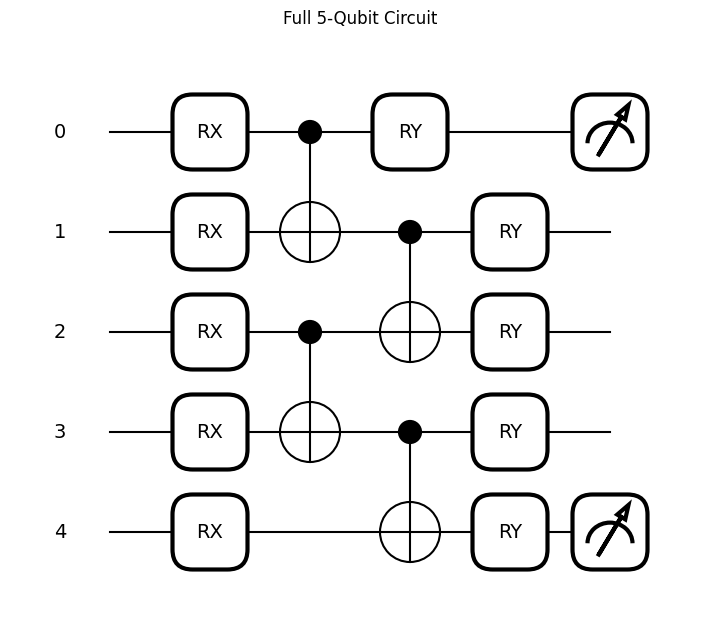

In [7]:
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

def circuit_blueprint(params):
    # Initial layer
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
    
    # Entangling gates in two blocks (0-1 and 2-4)
    qml.CNOT(wires=[0, 1])
    for i in range(2, 4):
        qml.CNOT(wires=[i, i+1])
        
    # HEAVY ENTANGLER (The bottleneck to cut!)
    # This gate connects the two blocks: wire 1 (group A) and wire 2 (group B)
    qml.CNOT(wires=[1, 2])

    # Final layer
    for i in range(n_qubits):
        qml.RY(params[i + n_qubits], wires=i)
        
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(4))

params = np.random.random(2 * n_qubits)
qnode_full = qml.QNode(circuit_blueprint, dev)

print("Starting simulation of full 5-qubit circuit...")
start_time = time.time()
full_res = qnode_full(params)
duration = time.time() - start_time
print(f"Full result: {full_res:.6f} (Time: {duration:.4f}s)")

# Visualize the circuit
qml.draw_mpl(qnode_full)(params)
plt.title("Full 5-Qubit Circuit")
plt.show()

## 3. Phase 1: Cutting (Manual & Automatic)

We will now identify the optimal cut to separate the circuit into two fragments.

Original Operations: 14
MultiDiGraph with 16 nodes and 15 edges


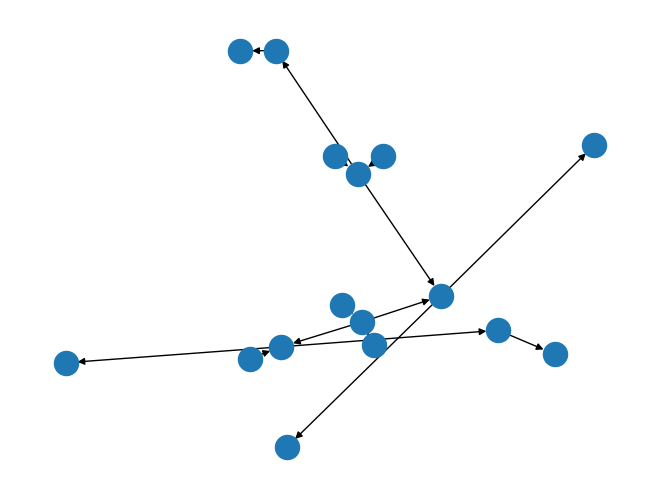

In [8]:
import pennylane.qcut as qcut

# Define the original circuit as a tape
with qml.tape.QuantumTape() as original_tape:
    circuit_blueprint(params)

print(f"Original Operations: {len(original_tape.operations)}")
original_graph = qcut.tape_to_graph(original_tape)

print(original_graph)
# 3. Print/Visualize graph
nx.draw(original_graph, with_labels=False)
plt.show()

Original Operations Count: 14
Circuit Graph:
MultiDiGraph with 16 nodes and 15 edges


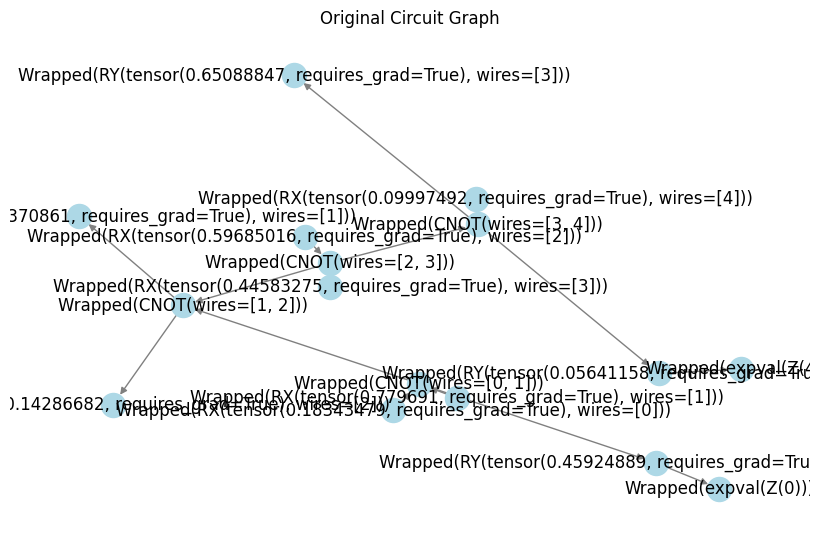

In [13]:
import pennylane.qcut as qcut

# Define the original circuit as a tape
with qml.tape.QuantumTape() as original_tape:
    circuit_blueprint(params)

print(f"Original Operations Count: {len(original_tape.operations)}")
original_graph = qcut.tape_to_graph(original_tape)

print("Circuit Graph:")
print(original_graph)
# Visualize graph nodes and edges briefly
plt.figure(figsize=(8, 5))
nx.draw(original_graph, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Original Circuit Graph")
plt.show()

# --- 3A. Manual Cutting ---
with qml.tape.QuantumTape() as manual_tape:
    for i in range(n_qubits):
        qml.RX(params[i], wires=i)
    qml.CNOT(wires=[0, 1])
    for i in range(2, 4):
        qml.CNOT(wires=[i, i+1])
    
    # --- MANUAL CUT PLACEMENT ---
    # We cut the connection at wire 2 just before the bottleneck CNOT(1, 2)
    qml.WireCut(wires=2)
    qml.CNOT(wires=[1, 2])
    
    for i in range(n_qubits):
        qml.RY(params[i + n_qubits], wires=i)
    qml.expval(qml.PauliZ(0) @ qml.PauliZ(4))



In [14]:
# --- 3B. Automatic Cutting ---
try:
    # Partition into subgraphs of max 3 qubits to force a cut
    auto_cut_graph = qcut.find_and_place_cuts(
        original_graph, 
        cut_strategy=qcut.CutStrategy(max_free_wires=3)
    )
    print("✅ Automatic cuts placed successfully via optimizer!")
except Exception as e:
    print(f"⚠️ Automatic cutting failed or KaHyPar is missing: {e}")
    print("   Falling back to manual cut placement.")
    auto_cut_graph = qcut.tape_to_graph(manual_tape)

# Visualize and report cut locations
auto_cut_tape = qcut.graph_to_tape(auto_cut_graph)
print("\n--- CUT LOCATIONS ---")
cuts = [op for op in auto_cut_tape.operations if isinstance(op, qml.WireCut)]
if not cuts:
    print("No cuts were placed.")
else:
    for i, op in enumerate(cuts):
        print(f"Cut {i+1}: Performed on Wire {op.wires.tolist()}")

qml.draw_mpl(auto_cut_tape)()
plt.title("Circuit with Automated Cuts")
plt.show()

✅ Automatic cuts placed successfully via optimizer!

--- CUT LOCATIONS ---
Cut 1: Performed on Wire [2]


TypeError: 'QuantumScript' object is not callable

## 4. Phase 2: Fragment Execution (Parallelized)

Fragmentation creates multiple subcircuits that need to be executed. We use `joblib` to speed this up.

In [11]:
# 1. Replace WireCut operators with Measure/Prepare (fragmentation)
qcut.replace_wire_cut_nodes(auto_cut_graph)
fragments, communication_graph = qcut.fragment_graph(auto_cut_graph)

print(f"Circuit divided into {len(fragments)} fragment groups.")
fragment_tapes = [qcut.graph_to_tape(f) for f in fragments]

# 2. Expand fragments into individual Quantum Tapes (tasks)
expanded = [qcut.expand_fragment_tape(t) for t in fragment_tapes]

configurations = []
prepare_nodes = []
measure_nodes = []
for config_tapes, p, m in expanded:
    configurations.append(config_tapes)
    prepare_nodes.append(p)
    measure_nodes.append(m)

tapes = tuple(tape for c in configurations for tape in c)
print(f"Total individual tapes to execute: {len(tapes)}")

# 3. Parallel Execution Task
def execute_on_device(tape):
    # Isolated device for each parallel worker
    dev_sub = qml.device("default.qubit", wires=tape.wires)
    # FIX: gradient_fn is deprecated/removed in modern qml.execute, use diff_method
    return qml.execute([tape], dev_sub, diff_method=None)[0]

print("Executing in parallel using joblib (n_jobs=-1)...")
start_time = time.time()
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(execute_on_device)(t) for t in tapes
)
parallel_duration = time.time() - start_time

print(f"Execution finished in {parallel_duration:.4f}s")

Circuit divided into 2 fragment groups.
Total individual tapes to execute: 7
Executing in parallel using joblib (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Execution finished in 1.4973s


[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    1.5s finished


## 5. Phase 3: Knitting (Post-processing)

We reconstruct the result by contracting the tensors from all fragment executions.

In [12]:
# 1. Knitting (Post-processing)
reconstructed_val = qcut.qcut_processing_fn(
    results, 
    communication_graph, 
    prepare_nodes, 
    measure_nodes
)

print(f"\n--- VALIDATION ---")
print(f"Original Result:      {full_res:.8f}")
print(f"Reconstructed Result: {reconstructed_val:.8f}")
print(f"Difference:           {np.abs(full_res - reconstructed_val):.2e}")
print(f"Success:              {np.isclose(full_res, reconstructed_val)}")


--- VALIDATION ---
Original Result:      0.65339023
Reconstructed Result: 0.65339023
Difference:           3.33e-16
Success:              True


## 6. Summary and Conclusion

In this tutorial, we successfully decomposed a 10-qubit circuit into two 5-qubit circuits. 

**Key Takeaways:**
- **Cutting**: Uses `qcut.find_and_place_cuts` or manual `qml.WireCut`.
- **Execution**: Using `joblib` allows for local multithreading of circuit tasks, which is essential as the number of tasks grows with the number of cuts.
- **Knitting**: The post-processing function handles the complex logic of combining results using the Quasi-Probability Method.

This approach allows running large quantum algorithms on small hardware, although it introduces a classical sampling/computation overhead.